# Where the duration disagrees most

The duration is the result this network exists for, so the windows to look at are the ones where
the model and the labeller disagree about **how long a phase lasted** - not the ones with the
worst per-sample score. They are different sets: a window can agree on 90% of samples and still
put every exhale a third of a second short.

Three failure modes get separate sections, because they call for different fixes:

- **A phase paired but mis-timed** - the model found the breath and got its length wrong.
- **A phase never paired** - the model did not produce anything that lines up with it. No duration
  error exists for these, so they are invisible in the Bland-Altman charts.
- **A ratio thrown off** - inhale and exhale each plausible, their ratio not.

Spans the window boundary cut are excluded throughout, as they are in the reports: their stored
length is the fragment, not the phase.

**The run is pinned below.** Do not switch this to "the newest run" - a notebook that picks the
latest silently re-points at whatever finished last, which is how a figure ends up describing a
different experiment than the text around it.

In [1]:
import sys
from pathlib import Path


def repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'phase').is_dir():
            return candidate
    raise RuntimeError(f'no inhale-exhale-training checkout at or above {start}')


REPO = repo_root(Path.cwd().resolve())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

try:
    import torch  # noqa: F401
except ModuleNotFoundError as missing:
    raise RuntimeError(
        f'{missing.name} is missing - select the inhale-exhale-training kernel') from missing
print(f'repo root {REPO}')

repo root /Users/yaelalon/inhale-exhale-training


In [2]:
import numpy as np
import pandas as pd
from IPython.display import Image, display

import report_folds as rf
from phase import durations, figures
from phase.decode import decode
from phase.labels import UNKNOWN
from phase.metrics import match_spans

RUN = REPO / 'outputs/2026-08-27/10-23-34'
OUT = REPO / 'out' / 'duration_outliers'
OUT.mkdir(parents=True, exist_ok=True)

folds = rf.load_run(RUN)
settings = rf.settings_of(RUN, folds, None, None)
COST, MIN_DURATION = settings['cost'], settings['min_duration']
IOU, PLOT = settings['event_iou'], settings['plot_cfg']
ensemble, windows = rf.ensemble_of(folds)
traces = rf.traces_for(RUN, ensemble['window_id'], ensemble['env'])

# One entry per test window: the two label arrays, the trace, and where it came from.
items = []
for index, window_id in enumerate(ensemble['window_id'].tolist()):
    key = (str(ensemble['env'][index]), int(window_id))
    if key not in traces:
        continue
    logits, truth = windows[index]
    items.append({durations.LABEL: truth,
                  durations.MODEL: decode(logits, COST, MIN_DURATION),
                  'values': traces[key]['values'],
                  'fps': float(ensemble['fps'][index]),
                  'env': key[0], 'window_id': key[1],
                  'signal': traces[key]['signal'],
                  'window_index': traces[key]['window_index'],
                  'patient': str(ensemble['patient'][index])})
print(f'{RUN.name}: {len(items)} test windows, '
      f'{len({i["patient"] for i in items})} patients, IoU {IOU}')

5 folds, 228 test windows each, 15 patients - window ids identical
labels.source = human, switch_penalty = 2.0, enforce_min = False, transition table = ['exhale', 'inhale', 'stop', 'unknown']


10-23-34: 228 test windows, 15 patients, IoU 0.5


## Scoring a window by its duration error

`span_errors` already returns one row per paired phase, carrying the window it came from - so the
per-window view is a groupby, not a second calculation. Two summaries per window:

- **worst** - the largest single error in it. This is what finds the one bad breath.
- **mean** - the average error size across its phases. This is what finds a window that is
  uniformly off, which is the more worrying of the two.

In [3]:
pairs, coverage = durations.span_errors(items, IOU)
pairs['abs_error'] = pairs[durations.ERROR].abs()

KEYS = ['env', 'signal', 'window_id', 'patient']
per_window = (pairs.groupby(KEYS)
              .agg(spans=('abs_error', 'size'),
                   worst=('abs_error', 'max'),
                   mean=('abs_error', 'mean'),
                   signed=(durations.ERROR, 'mean'))
              .reset_index())

# Which phase carried the worst error in each window, for the panel titles.
worst_phase = (pairs.sort_values('abs_error')
               .groupby(KEYS)
               .last()[['phase', durations.ERROR, f'{durations.LABEL}_sec',
                        f'{durations.MODEL}_sec']]
               .rename(columns={'phase': 'worst_phase', durations.ERROR: 'worst_signed',
                                f'{durations.LABEL}_sec': 'worst_labelled',
                                f'{durations.MODEL}_sec': 'worst_model'})
               .reset_index())
per_window = per_window.merge(worst_phase, on=KEYS)
# Per-sample agreement, joined on the same key, so the two views can be compared.
agreement = pd.DataFrame([{**{k: i[k] for k in KEYS},
                           'agreement': float((i[durations.MODEL] == i[durations.LABEL]).mean())}
                          for i in items])
per_window = per_window.merge(agreement, on=KEYS)
per_window.to_csv(OUT / 'per_window_duration_error.csv', index=False)

print(f'{len(per_window)} windows carry at least one paired phase '
      f'(of {len(items)} in the test set)')
print(per_window[['worst', 'mean']].describe().loc[['50%', '75%', 'max']].round(2).to_string())
per_window.sort_values('worst', ascending=False).head(12)[
    KEYS + ['spans', 'worst', 'worst_phase', 'worst_labelled', 'worst_model', 'mean',
            'agreement']].round(2)

192 windows carry at least one paired phase (of 228 in the test set)
     worst  mean
50%   0.50  0.17
75%   0.78  0.24
max   1.67  0.80


,env,signal,window_id,patient,spans,worst,worst_phase,worst_labelled,worst_model,mean,agreement
72,ds_prod,17317550,1861,RM-005,9,1.67,exhale/inhale,3.67,2.00,0.44,0.43
30,ds_algo,1800925,1356,SL0063,11,1.61,exhale/inhale,3.50,1.89,0.80,0.74
86,ds_prod,17456851,257,bs-002,14,1.50,exhale,3.40,1.90,0.47,0.76
133,ds_prod,17887492,2665,RM-017,15,1.50,exhale,3.70,2.20,0.33,0.85
156,ds_prod,18161970,1309,ICH-007,9,1.50,exhale,3.70,2.20,0.55,0.74
67,ds_prod,17279395,786,bs-009,7,1.44,exhale/inhale,3.33,1.89,0.37,0.84
27,ds_algo,1798830,255,SL0063,12,1.42,exhale/inhale,3.62,2.20,0.56,0.86
159,ds_prod,18171218,2622,RM-017,11,1.40,exhale,3.20,1.80,0.57,0.73
12,ds_algo,1582659,1198,SL0059,28,1.40,exhale/inhale,3.40,2.00,0.13,0.91
78,ds_prod,17341698,2250,RM-010,15,1.34,exhale/inhale,2.70,1.36,0.23,0.80


## Is the worst duration error the worst window?

If the two rankings agreed, the existing worst-first pages would already show these windows and
this notebook would be redundant. The correlation below says whether that is so.

In [4]:
order_duration = per_window.sort_values('worst', ascending=False)
top_duration = set(map(tuple, order_duration.head(20)[KEYS].to_numpy()))
top_score = set(map(tuple, per_window.sort_values('agreement').head(20)[KEYS].to_numpy()))
overlap = len(top_duration & top_score)

print(f'worst 20 by duration error vs worst 20 by per-sample agreement: '
      f'{overlap} windows in common')
print(f'correlation between per-window agreement and worst duration error: '
      f'{per_window.agreement.corr(per_window.worst):.2f}')
print()
print('the worst duration errors sit at these agreement scores:')
print(order_duration.head(10)[['worst', 'worst_phase', 'agreement']].round(2).to_string(
    index=False))

worst 20 by duration error vs worst 20 by per-sample agreement: 1 windows in common
correlation between per-window agreement and worst duration error: -0.13

the worst duration errors sit at these agreement scores:
 worst   worst_phase  agreement
  1.67 exhale/inhale       0.43
  1.61 exhale/inhale       0.74
  1.50        exhale       0.76
  1.50        exhale       0.85
  1.50        exhale       0.74
  1.44 exhale/inhale       0.84
  1.42 exhale/inhale       0.86
  1.40        exhale       0.73
  1.40 exhale/inhale       0.91
  1.34 exhale/inhale       0.80


## The windows with the largest single duration error

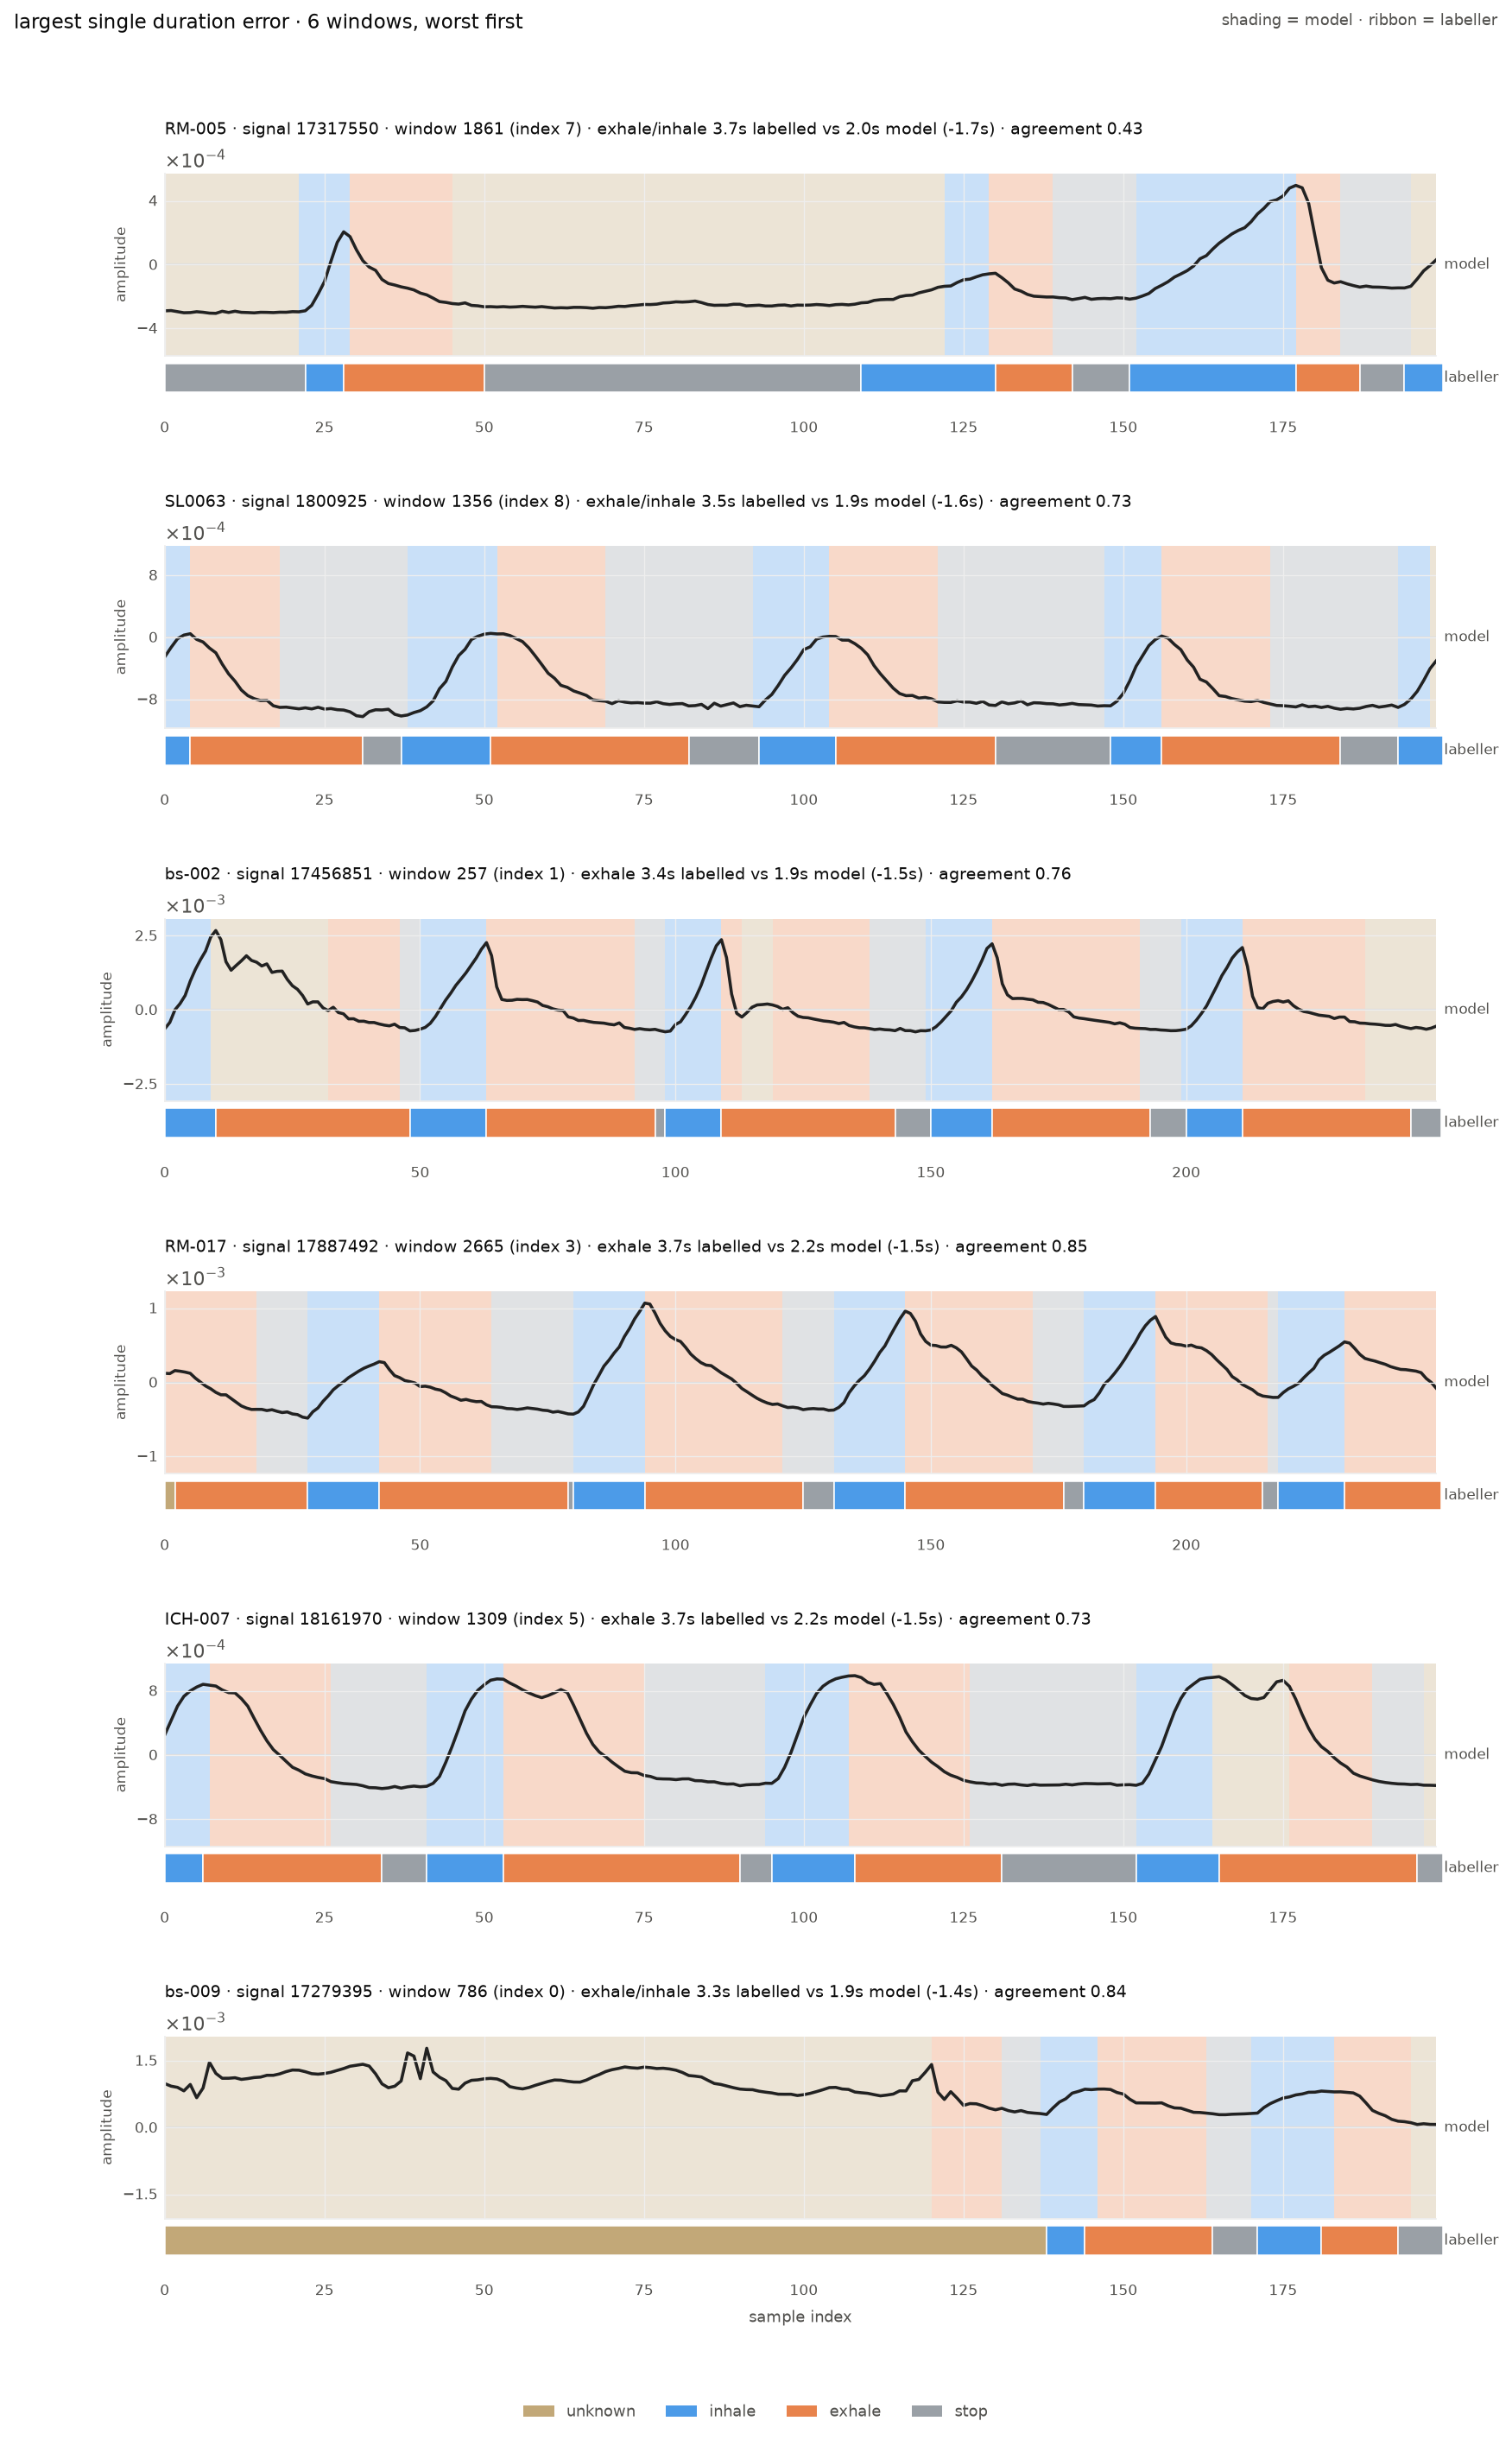

In [5]:
def draw(chosen: pd.DataFrame, name: str, heading: str) -> Path:
    """Panels for a set of windows, titled with what went wrong in each."""
    by_key = {(i['env'], i['signal'], i['window_id'], i['patient']): i for i in items}
    panels = []
    for row in chosen.itertuples():
        item = by_key[(row.env, row.signal, row.window_id, row.patient)]
        panels.append({
            'values': item['values'], 'reference': item[durations.LABEL],
            'prediction': item[durations.MODEL], 'fps': item['fps'],
            'title': (f"{row.patient} · signal {row.signal} · window {row.window_id} "
                      f"(index {item['window_index']}) · {row.worst_phase} "
                      f"{row.worst_labelled:.1f}s labelled vs {row.worst_model:.1f}s model "
                      f"({row.worst_signed:+.1f}s) · agreement {row.agreement:.2f}")})
    return figures.plot_windows(panels, OUT / name, heading, 'labeller', PLOT,
                                prediction_name='model',
                                caption='shading = model · ribbon = labeller')


path = draw(order_duration.head(6), 'worst_single_error.png',
            'largest single duration error · 6 windows, worst first')
display(Image(filename=str(path)))

## The windows that are uniformly off

Ranked by mean error size rather than the worst one. A window here has no single dramatic breath -
every phase in it is somewhat wrong, which is the harder failure to explain away.

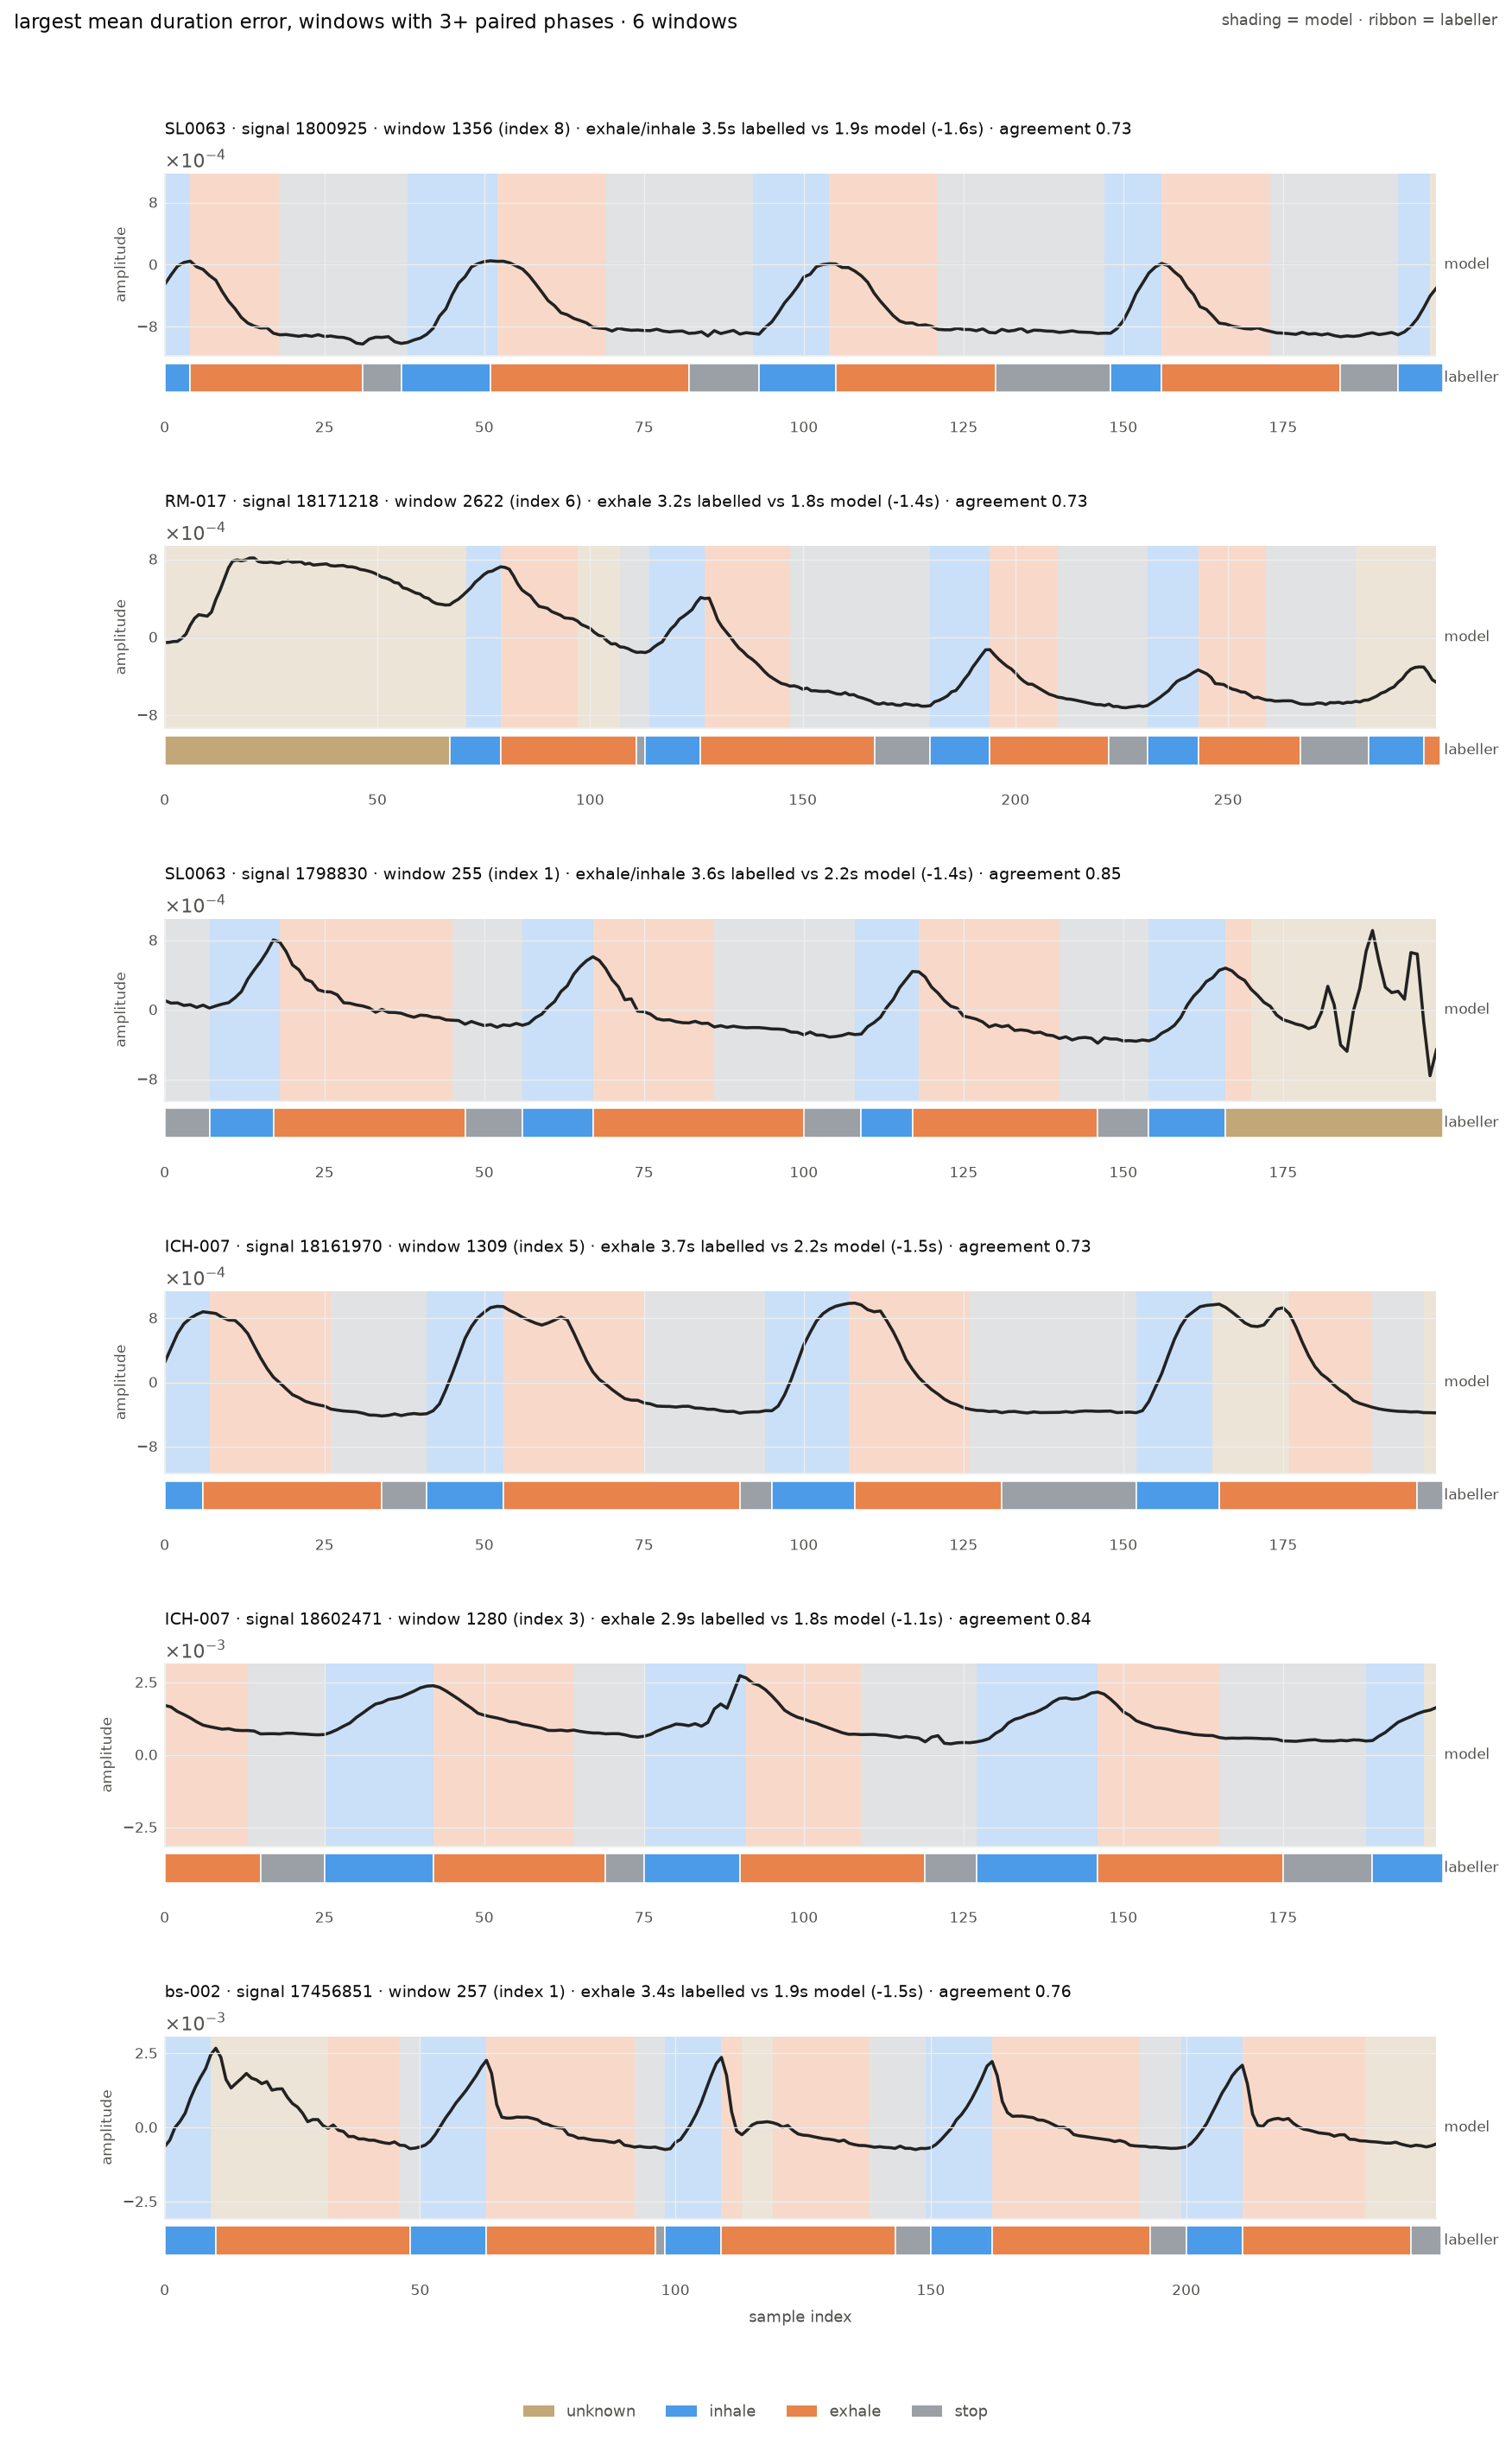

,env,signal,window_id,patient,spans,mean,worst,signed,agreement
30,ds_algo,1800925,1356,SL0063,11,0.80,1.61,-0.63,0.74
159,ds_prod,18171218,2622,RM-017,11,0.57,1.40,-0.48,0.73
27,ds_algo,1798830,255,SL0063,12,0.56,1.42,-0.38,0.86
156,ds_prod,18161970,1309,ICH-007,9,0.55,1.50,-0.44,0.74
186,ds_prod,18602471,1280,ICH-007,12,0.49,1.10,-0.21,0.84
86,ds_prod,17456851,257,bs-002,14,0.47,1.50,-0.37,0.76
72,ds_prod,17317550,1861,RM-005,9,0.44,1.67,-0.22,0.43
31,ds_algo,1801049,1339,SL0063,14,0.42,1.00,-0.31,0.77
7,ds_algo,1570033,1085,SL0057,8,0.42,0.80,-0.02,0.68
74,ds_prod,17320922,1589,RM-001,10,0.39,0.90,-0.39,0.83


In [6]:
# At least three paired phases, or a window with one bad breath tops a "uniformly off" ranking.
uniform = (per_window[per_window.spans >= 3]
           .sort_values('mean', ascending=False))
path = draw(uniform.head(6), 'uniformly_off.png',
            'largest mean duration error, windows with 3+ paired phases · 6 windows')
display(Image(filename=str(path)))
uniform.head(10)[KEYS + ['spans', 'mean', 'worst', 'signed', 'agreement']].round(2)

## Worst per phase

Pooling the phases hides which one is failing where: exhale is called short across the set and the
pause is called long, so a pooled ranking is mostly whichever phase has the widest spread.

inhale: worst 4 errors -1.1s, -0.9s, -0.7s, -0.7s


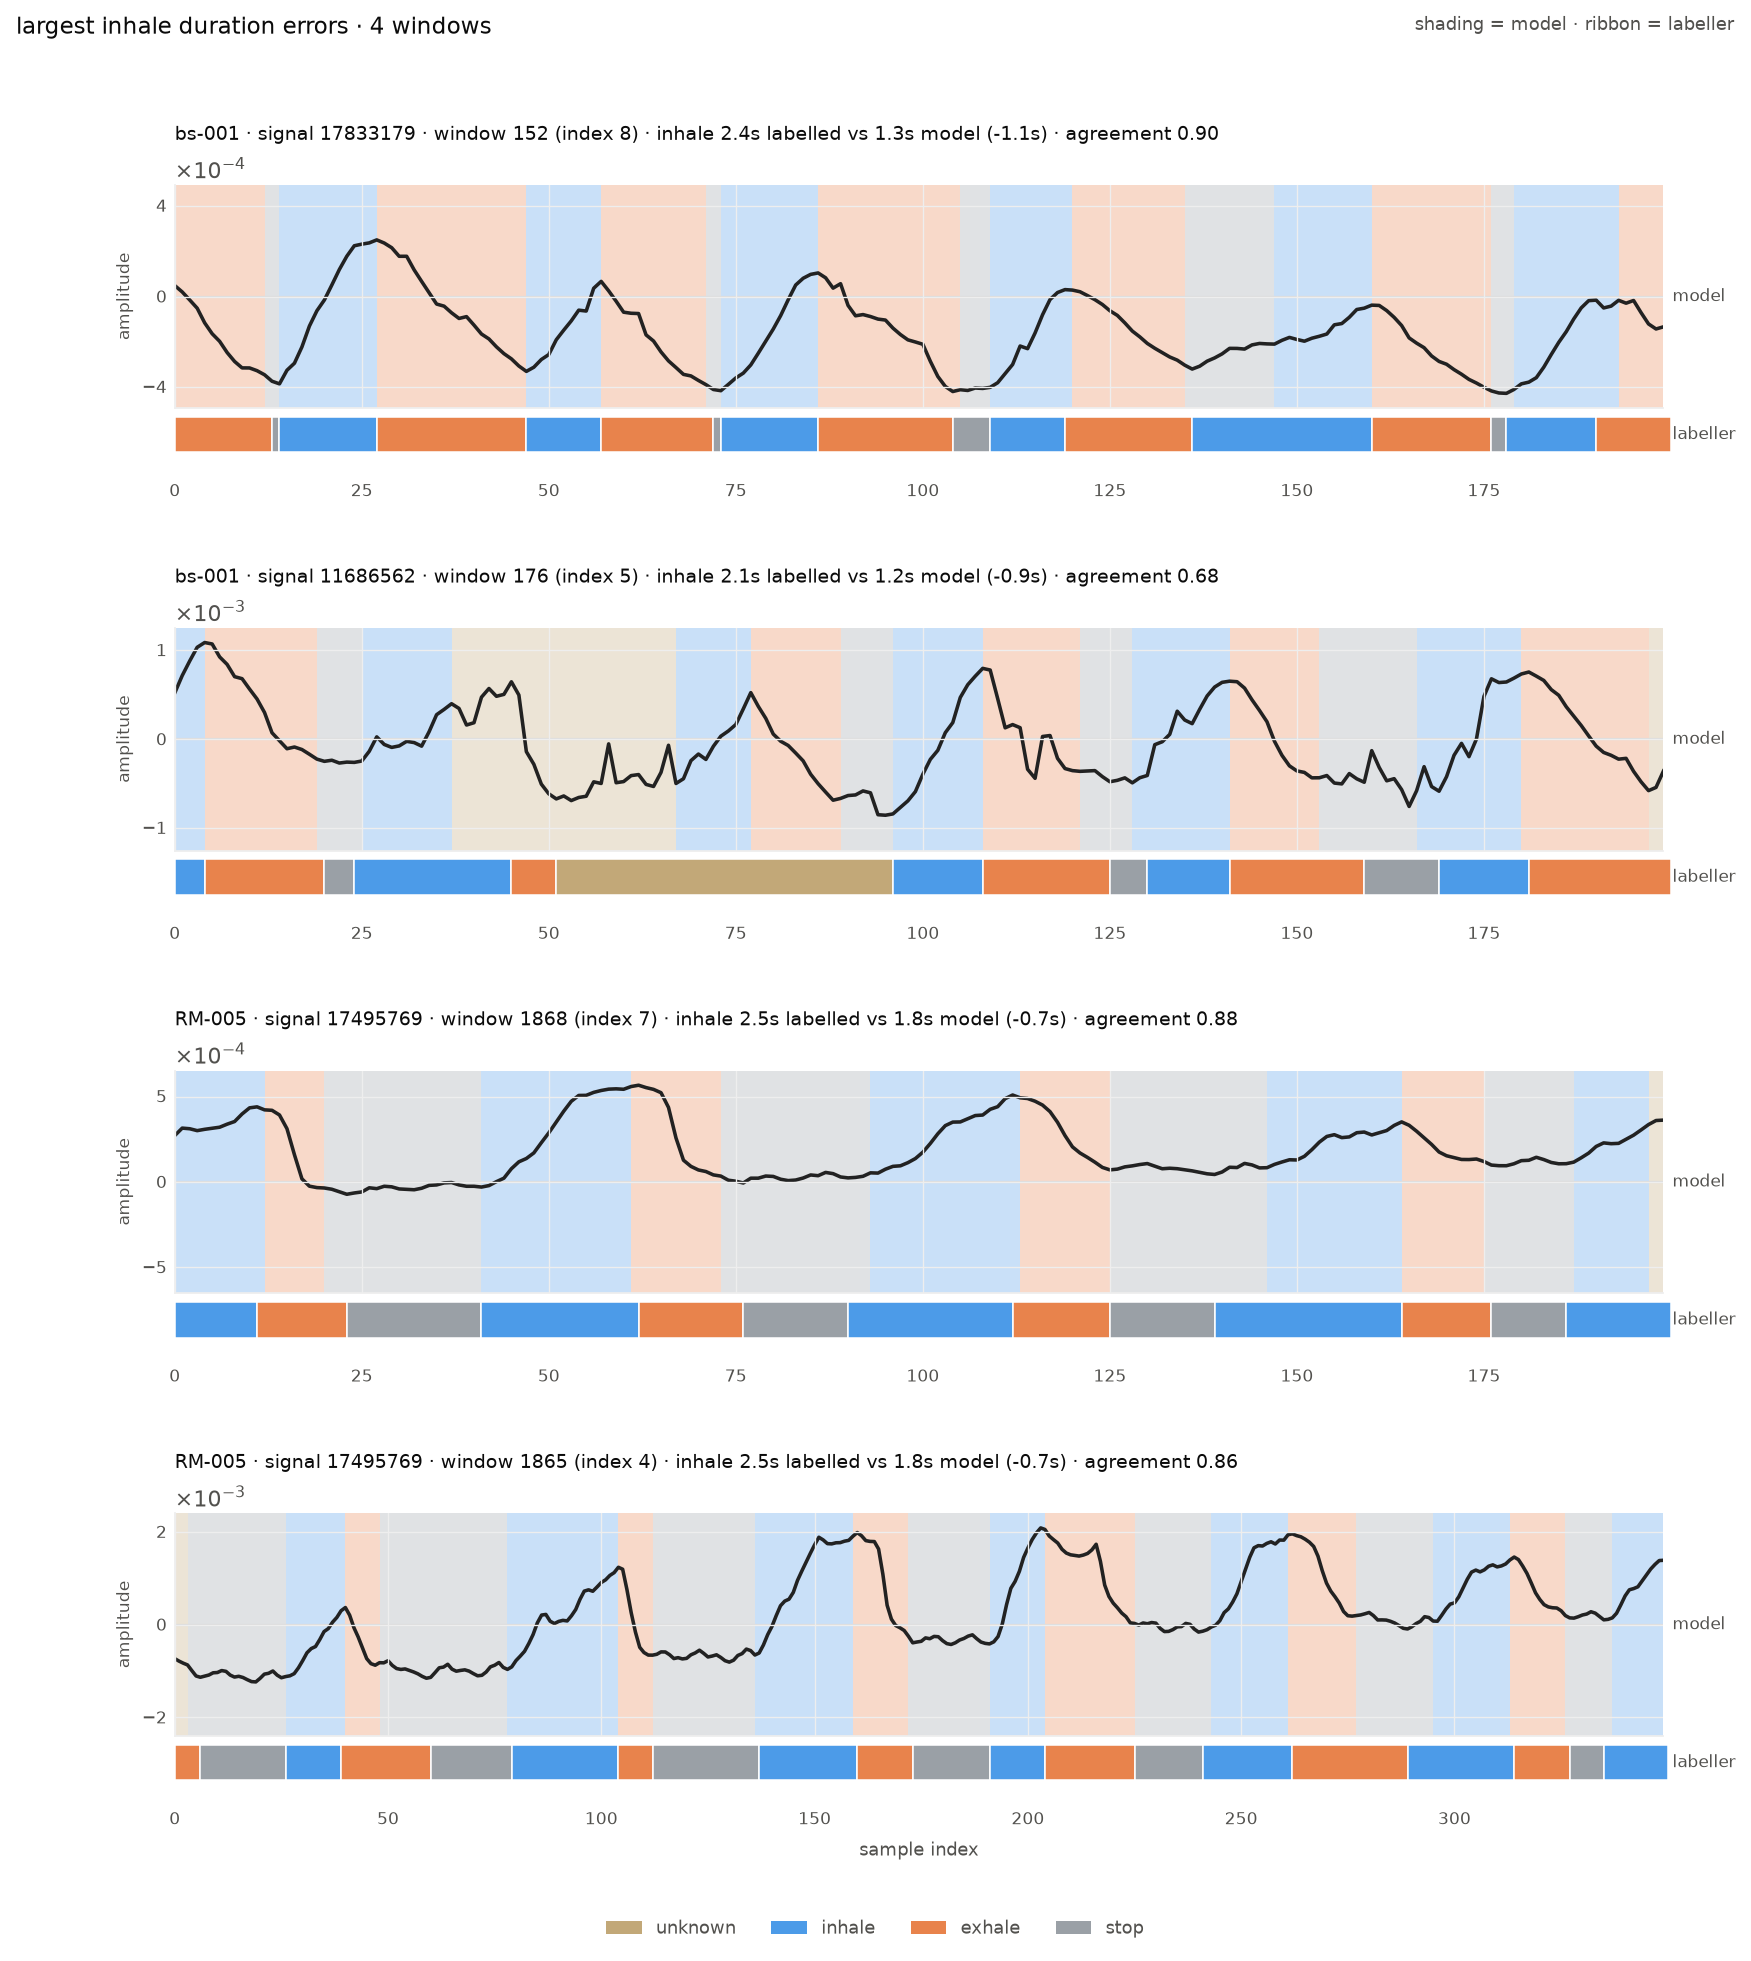

exhale: worst 4 errors -1.5s, -1.5s, -1.5s, -1.4s


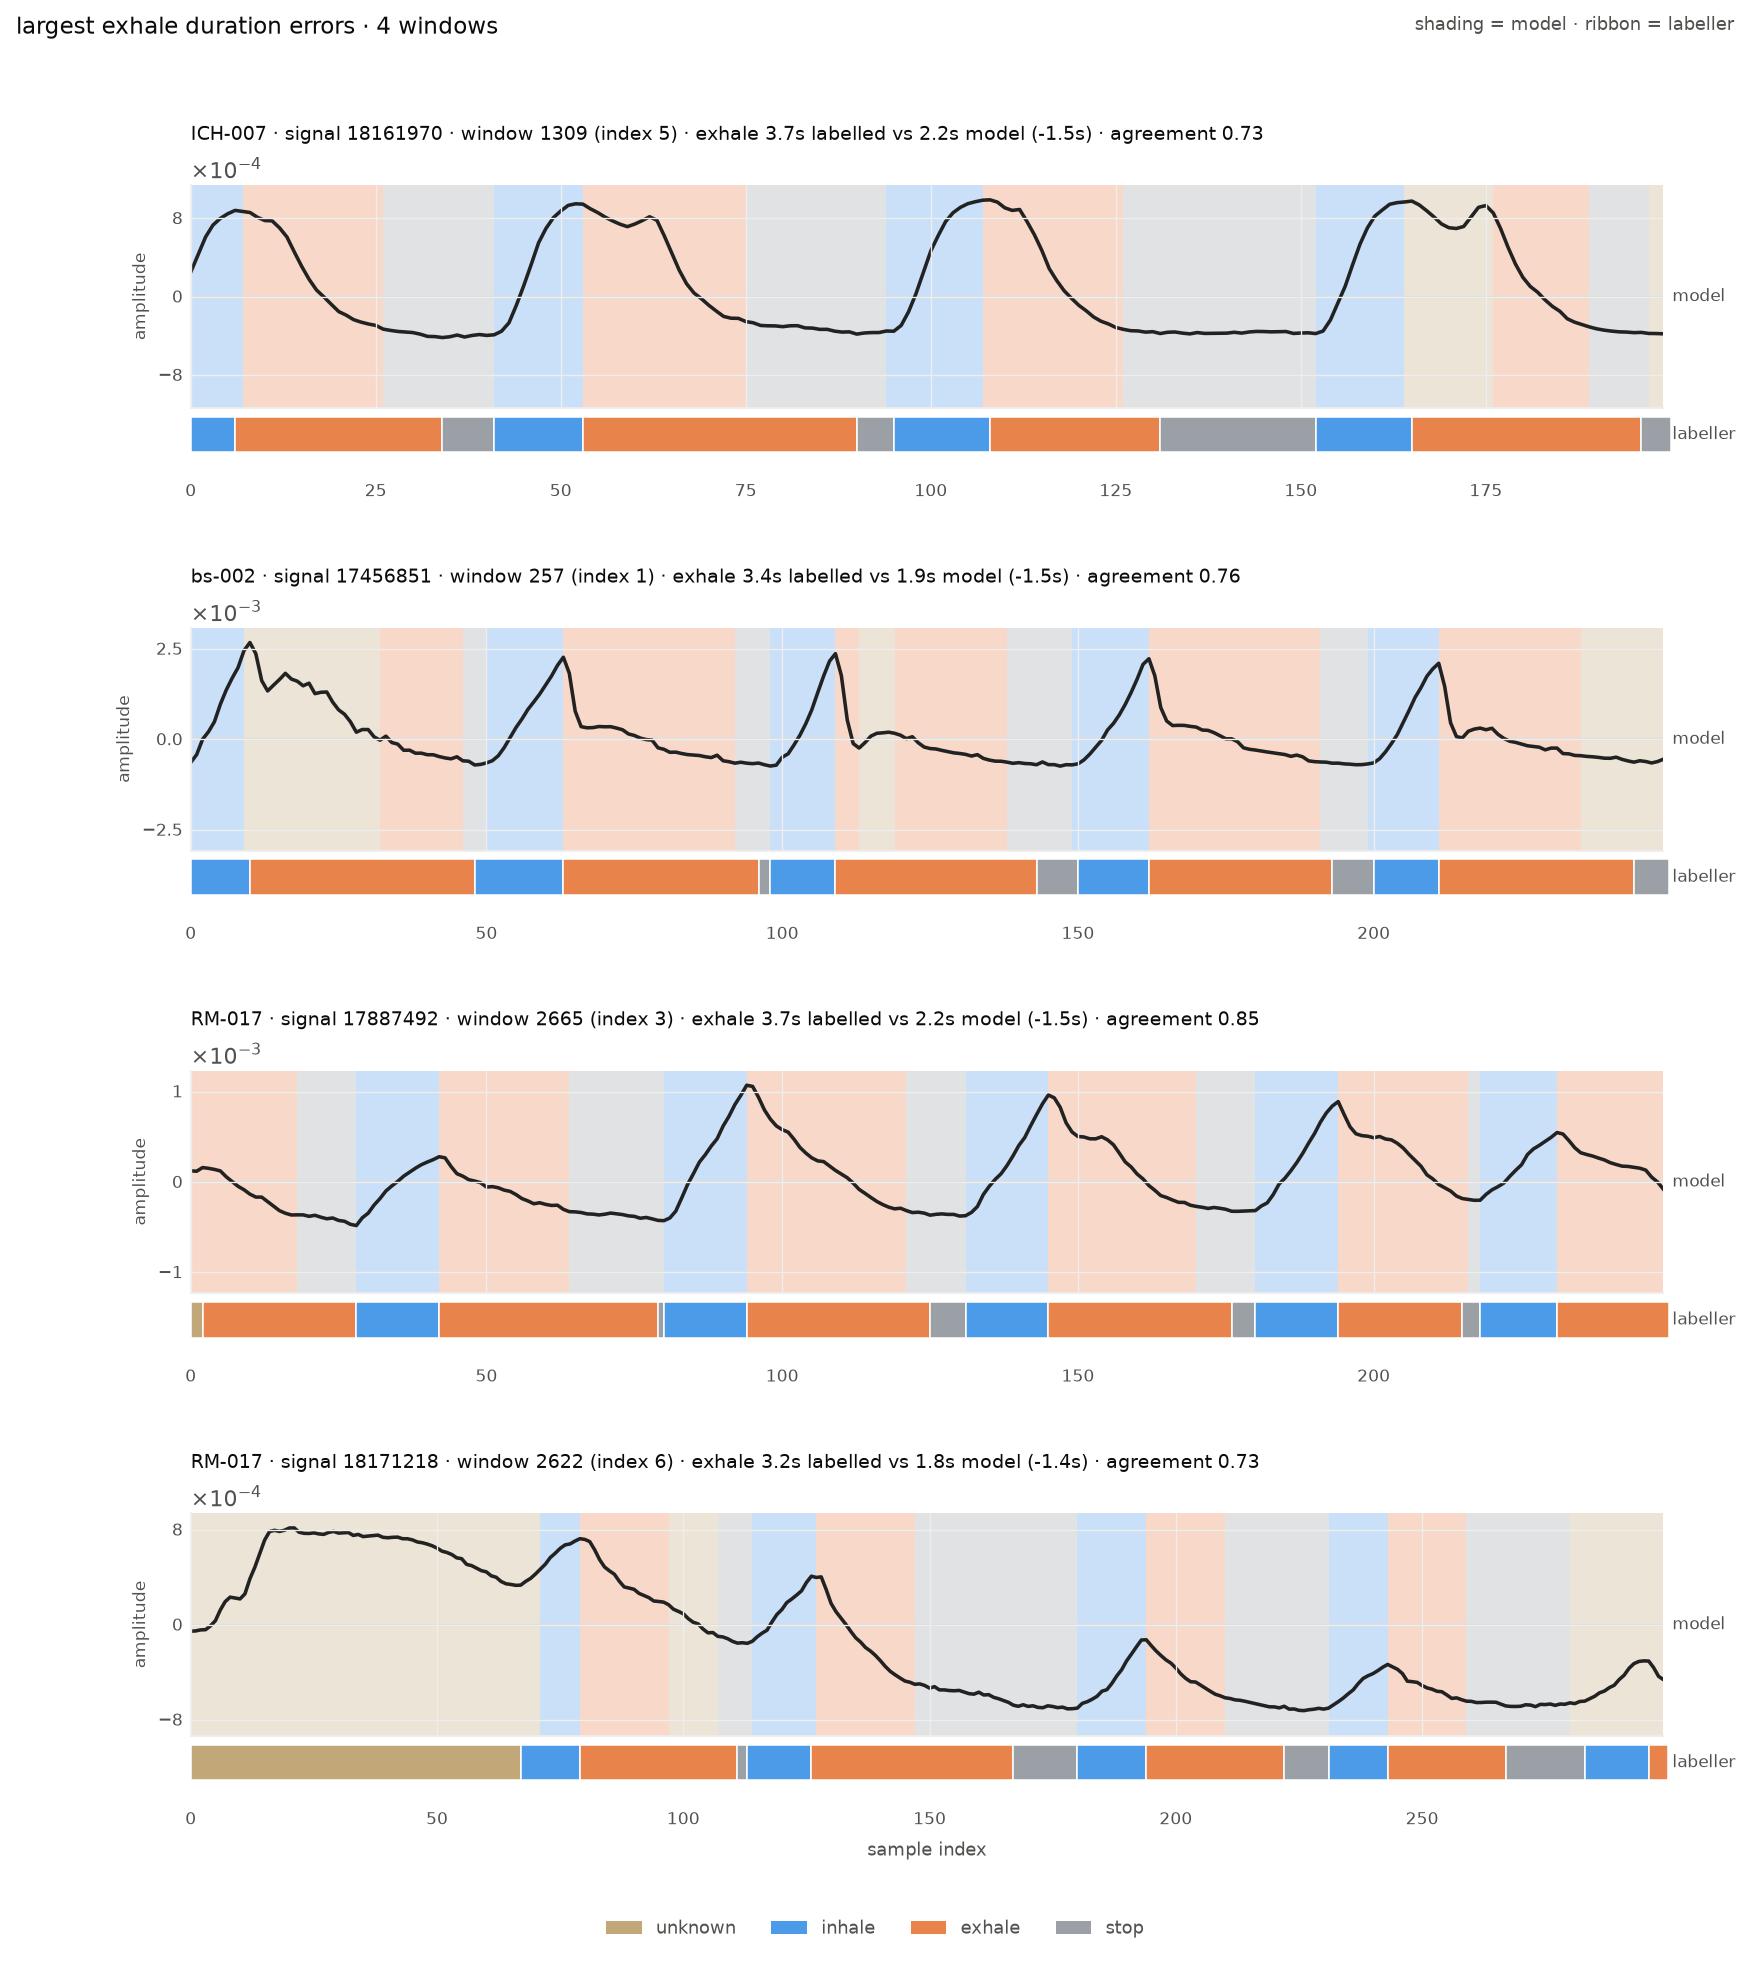

stop: worst 4 errors +1.1s, +1.1s, +1.0s, +0.9s


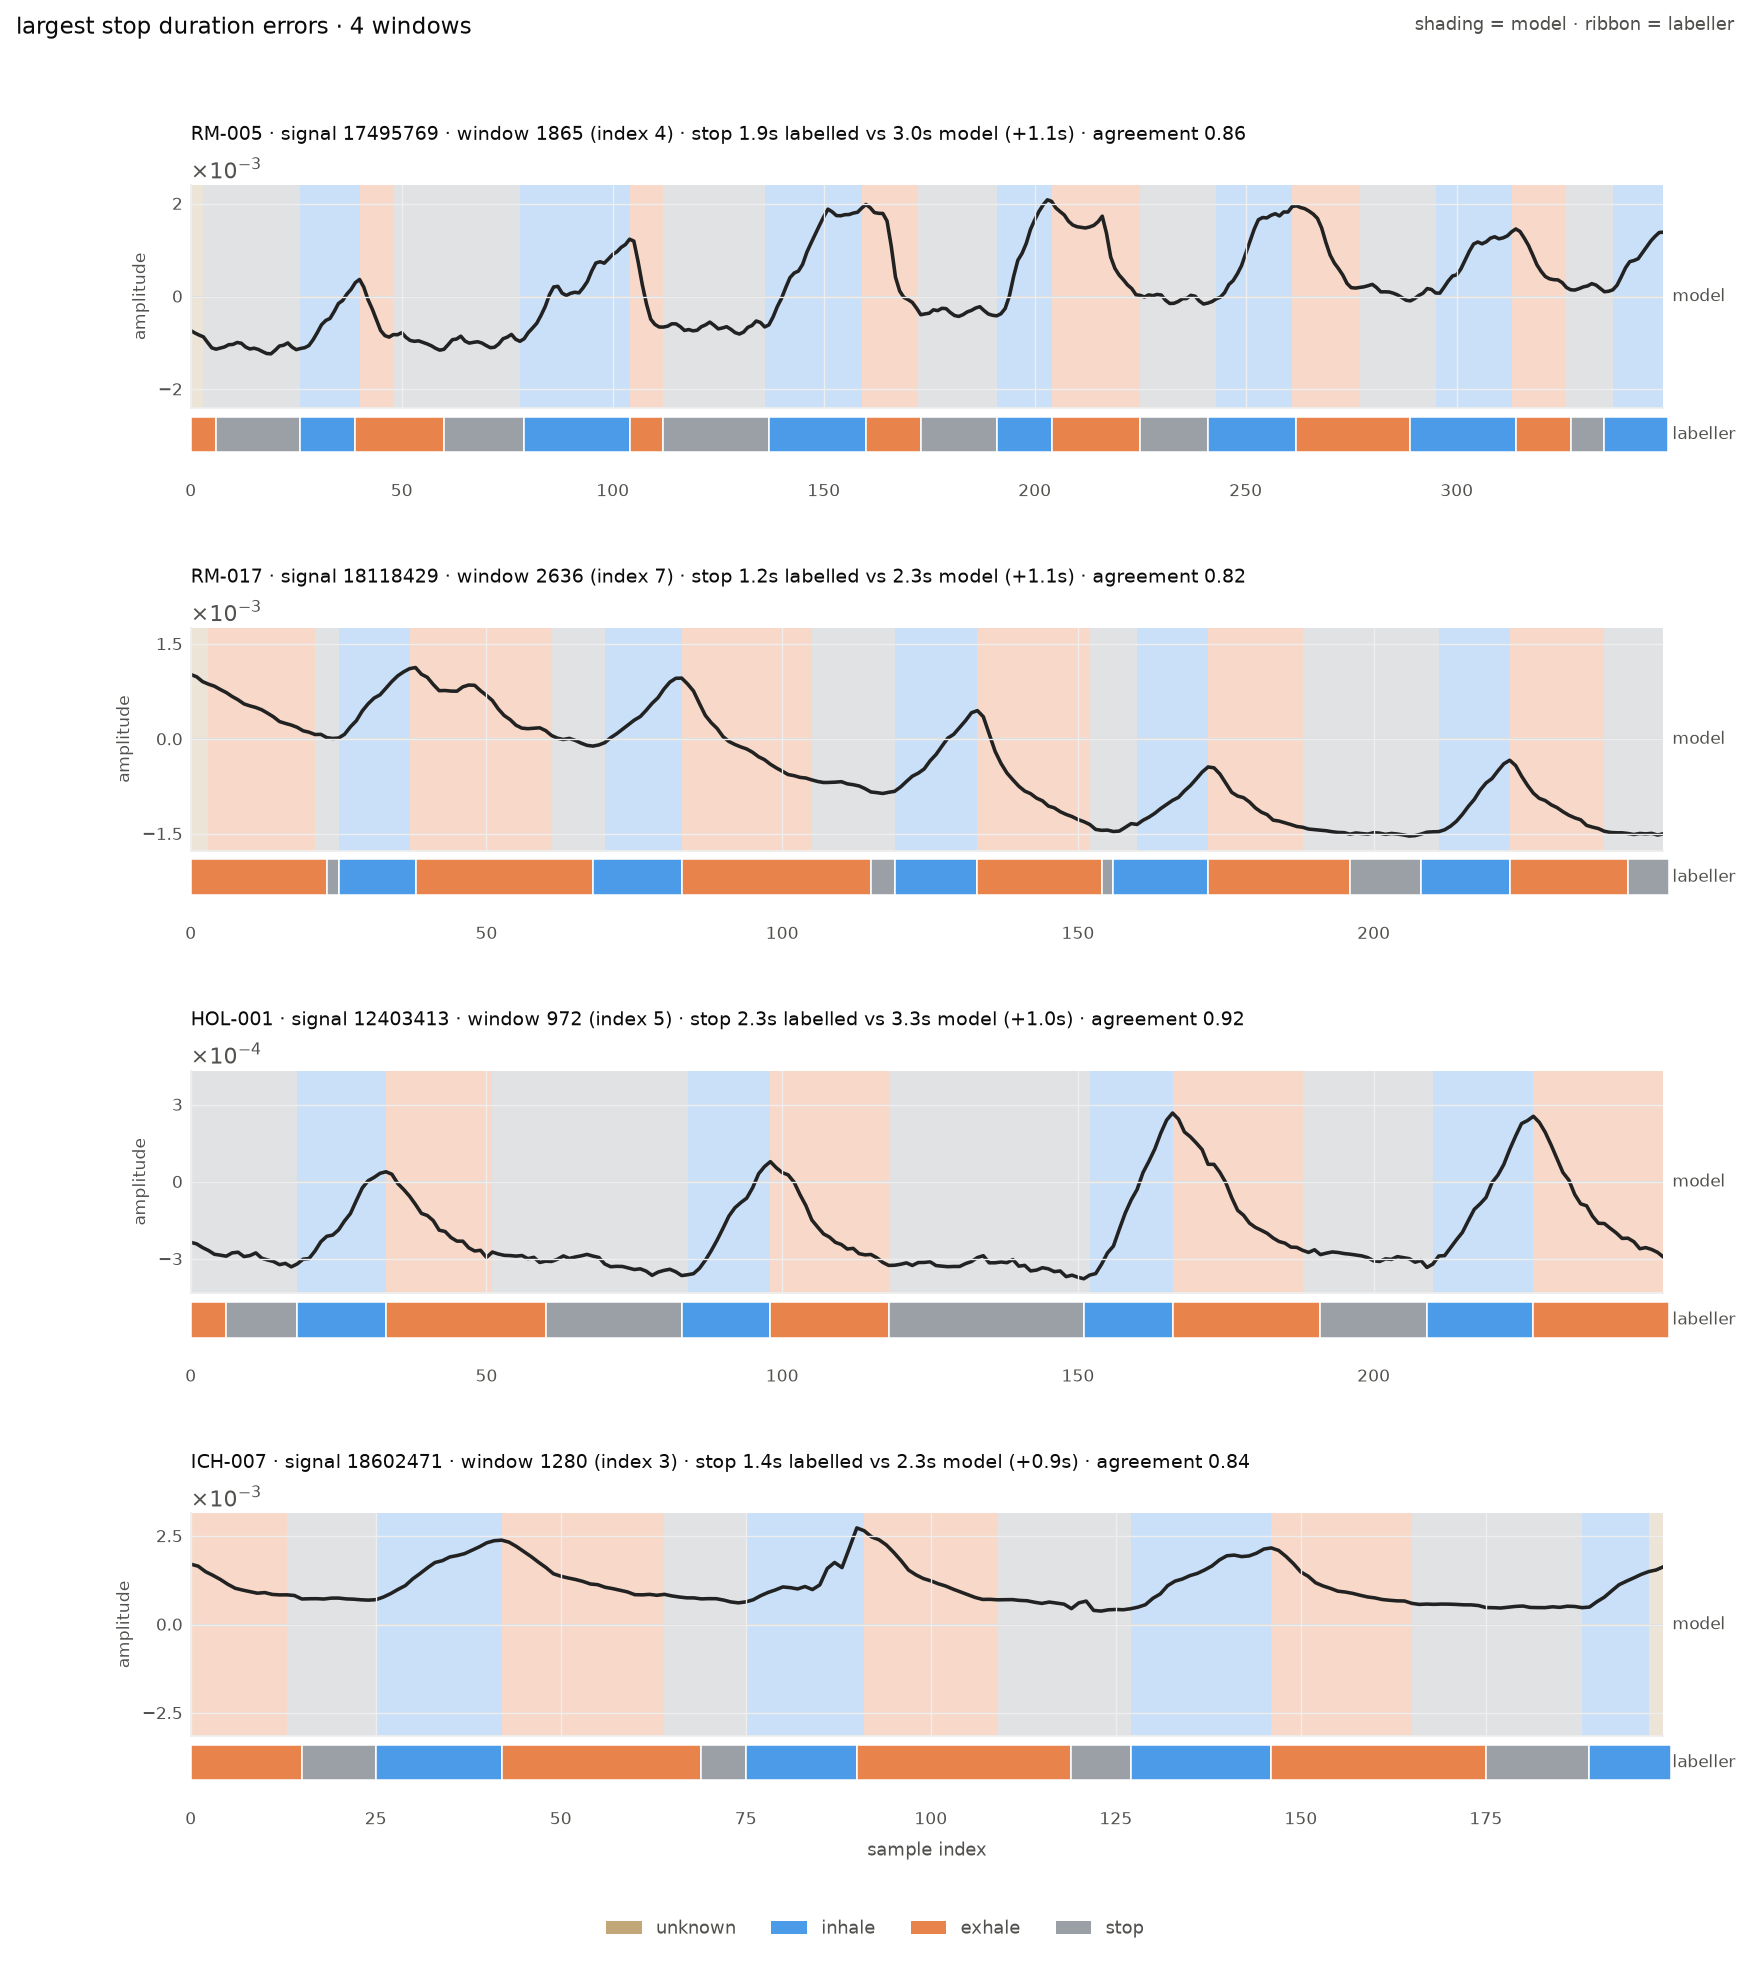

In [7]:
for phase in durations.MEASURED:
    sub = pairs[pairs.phase == phase].sort_values('abs_error', ascending=False)
    if not len(sub):
        continue
    chosen = (sub.head(4).merge(per_window.drop(
        columns=['worst_phase', 'worst_signed', 'worst_labelled', 'worst_model']), on=KEYS))
    chosen = chosen.assign(worst_phase=phase,
                           worst_signed=chosen[durations.ERROR],
                           worst_labelled=chosen[f'{durations.LABEL}_sec'],
                           worst_model=chosen[f'{durations.MODEL}_sec'])
    path = draw(chosen, f'worst_{phase}.png',
                f'largest {phase} duration errors · 4 windows')
    print(f'{phase}: worst 4 errors '
          + ', '.join(f'{v:+.1f}s' for v in sub.head(4)[durations.ERROR]))
    display(Image(filename=str(path)))

## Phases the model never answered

These carry **no** duration error, so they do not appear anywhere in the Bland-Altman charts - the
charts describe only the breaths that were paired. A window full of misses looks clean there and is
the reason the coverage column sits beside every duration figure.

357 labelled phases the model never answered
          n  median_seconds  share_called_unknown
phase                                            
exhale   91             1.2                  0.70
inhale   61             1.2                  0.94
stop    205             0.3                  0.28


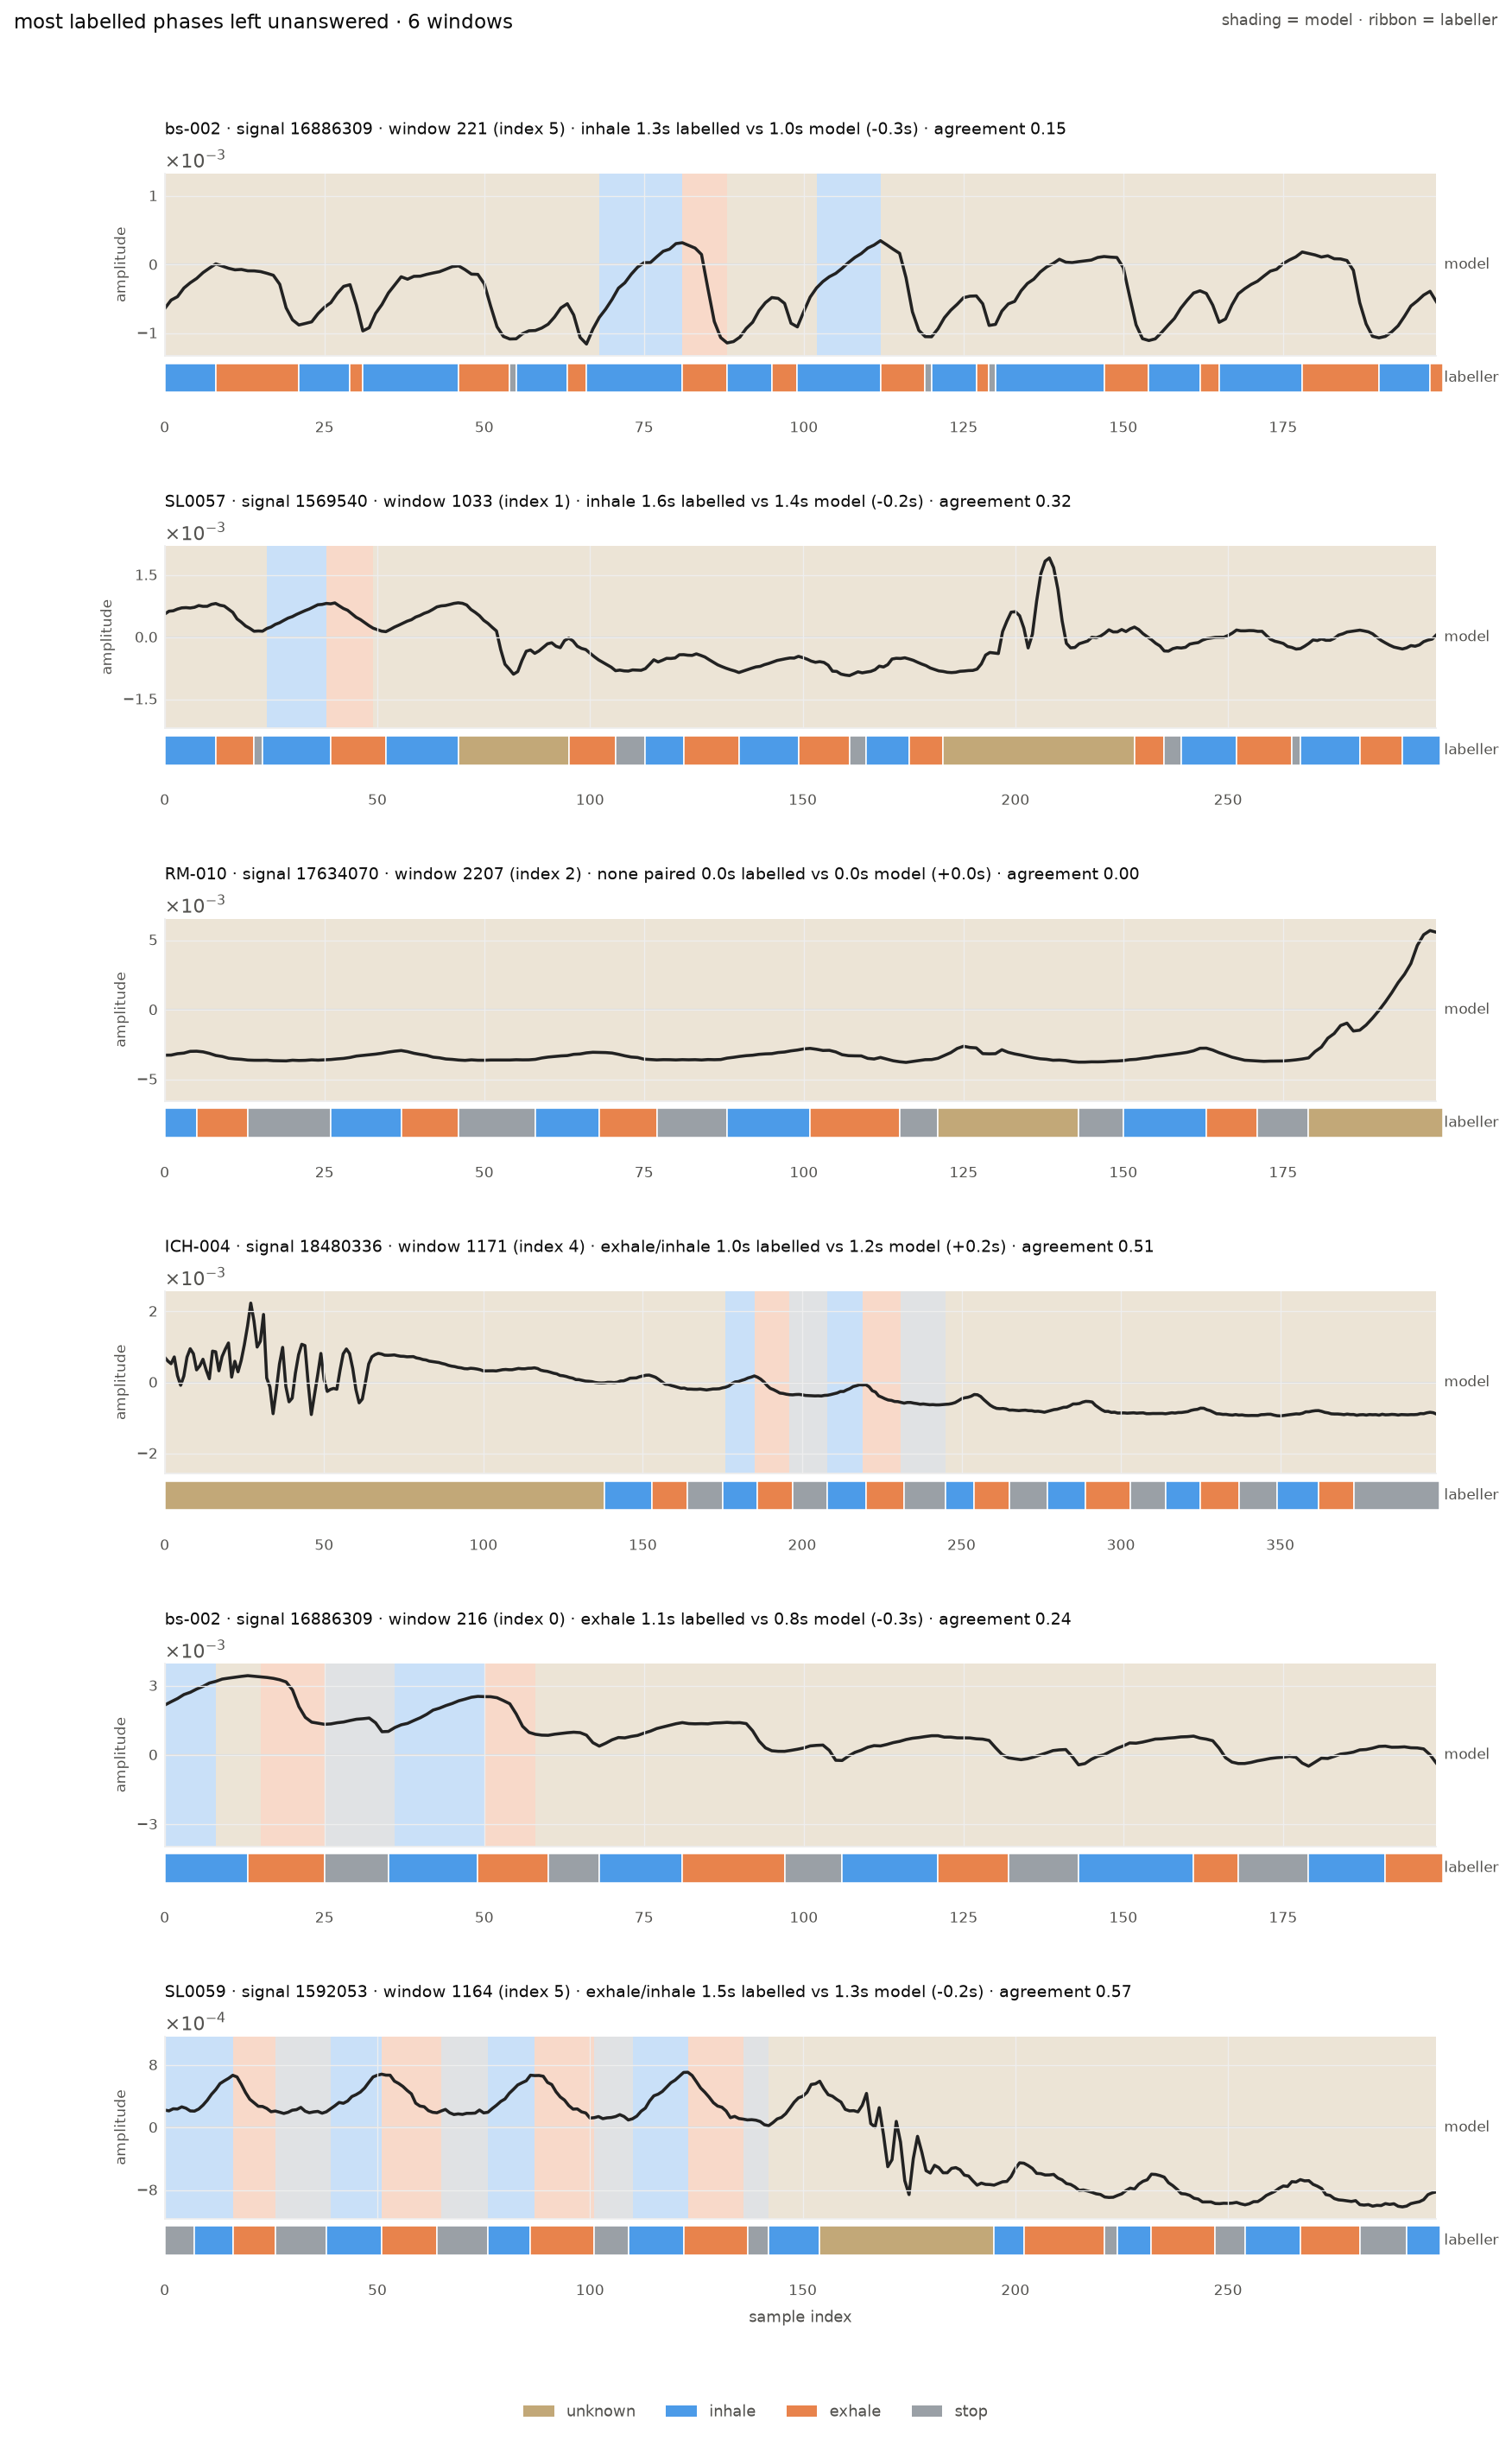

,env,signal,window_id,patient,misses
48,ds_prod,16886309,221,bs-002,22
2,ds_algo,1569540,1033,SL0057,19
81,ds_prod,17634070,2207,RM-010,15
125,ds_prod,18480336,1171,ICH-004,14
46,ds_prod,16886309,216,bs-002,11
12,ds_algo,1592053,1164,SL0059,11
77,ds_prod,17612480,2197,RM-010,9
26,ds_algo,1904987,1479,SL0065,9
27,ds_algo,1904987,1480,SL0065,7
68,ds_prod,17505279,2239,RM-010,6


In [8]:
missed = []
for item in items:
    for phase in durations.MEASURED:
        labelled = durations.interior_spans(item[durations.LABEL], phase)
        called = durations.interior_spans(item[durations.MODEL], phase)
        paired = {(a['start'], a['end']) for a, _, _ in match_spans(labelled, called, IOU)}
        for span in labelled:
            if (span['start'], span['end']) not in paired:
                block = item[durations.MODEL][span['start']:span['end']]
                missed.append({**{k: item[k] for k in KEYS}, 'phase': phase,
                               'seconds': (span['end'] - span['start']) / item['fps'],
                               'called_unknown': float((block == UNKNOWN).mean())})
missed = pd.DataFrame(missed)
missed.to_csv(OUT / 'unpaired_phases.csv', index=False)

print(f'{len(missed)} labelled phases the model never answered')
print(missed.groupby('phase').agg(n=('seconds', 'size'),
                                  median_seconds=('seconds', 'median'),
                                  share_called_unknown=('called_unknown', 'mean')).round(2)
      .to_string())

worst_misses = (missed.groupby(KEYS).size().rename('misses').reset_index()
                .sort_values('misses', ascending=False))
chosen = worst_misses.head(6).merge(per_window, on=KEYS, how='left')
chosen = chosen.assign(worst_phase=chosen.worst_phase.fillna('none paired'),
                       worst_labelled=chosen.worst_labelled.fillna(0.0),
                       worst_model=chosen.worst_model.fillna(0.0),
                       worst_signed=chosen.worst_signed.fillna(0.0),
                       agreement=chosen.agreement.fillna(0.0))
path = draw(chosen, 'most_unpaired.png',
            'most labelled phases left unanswered · 6 windows')
display(Image(filename=str(path)))
worst_misses.head(10)

## Ratios thrown off

A breath where inhale and exhale are each within tolerance but their ratio is not - or the reverse.
This is the case a per-phase table cannot show, because neither phase looks wrong on its own.

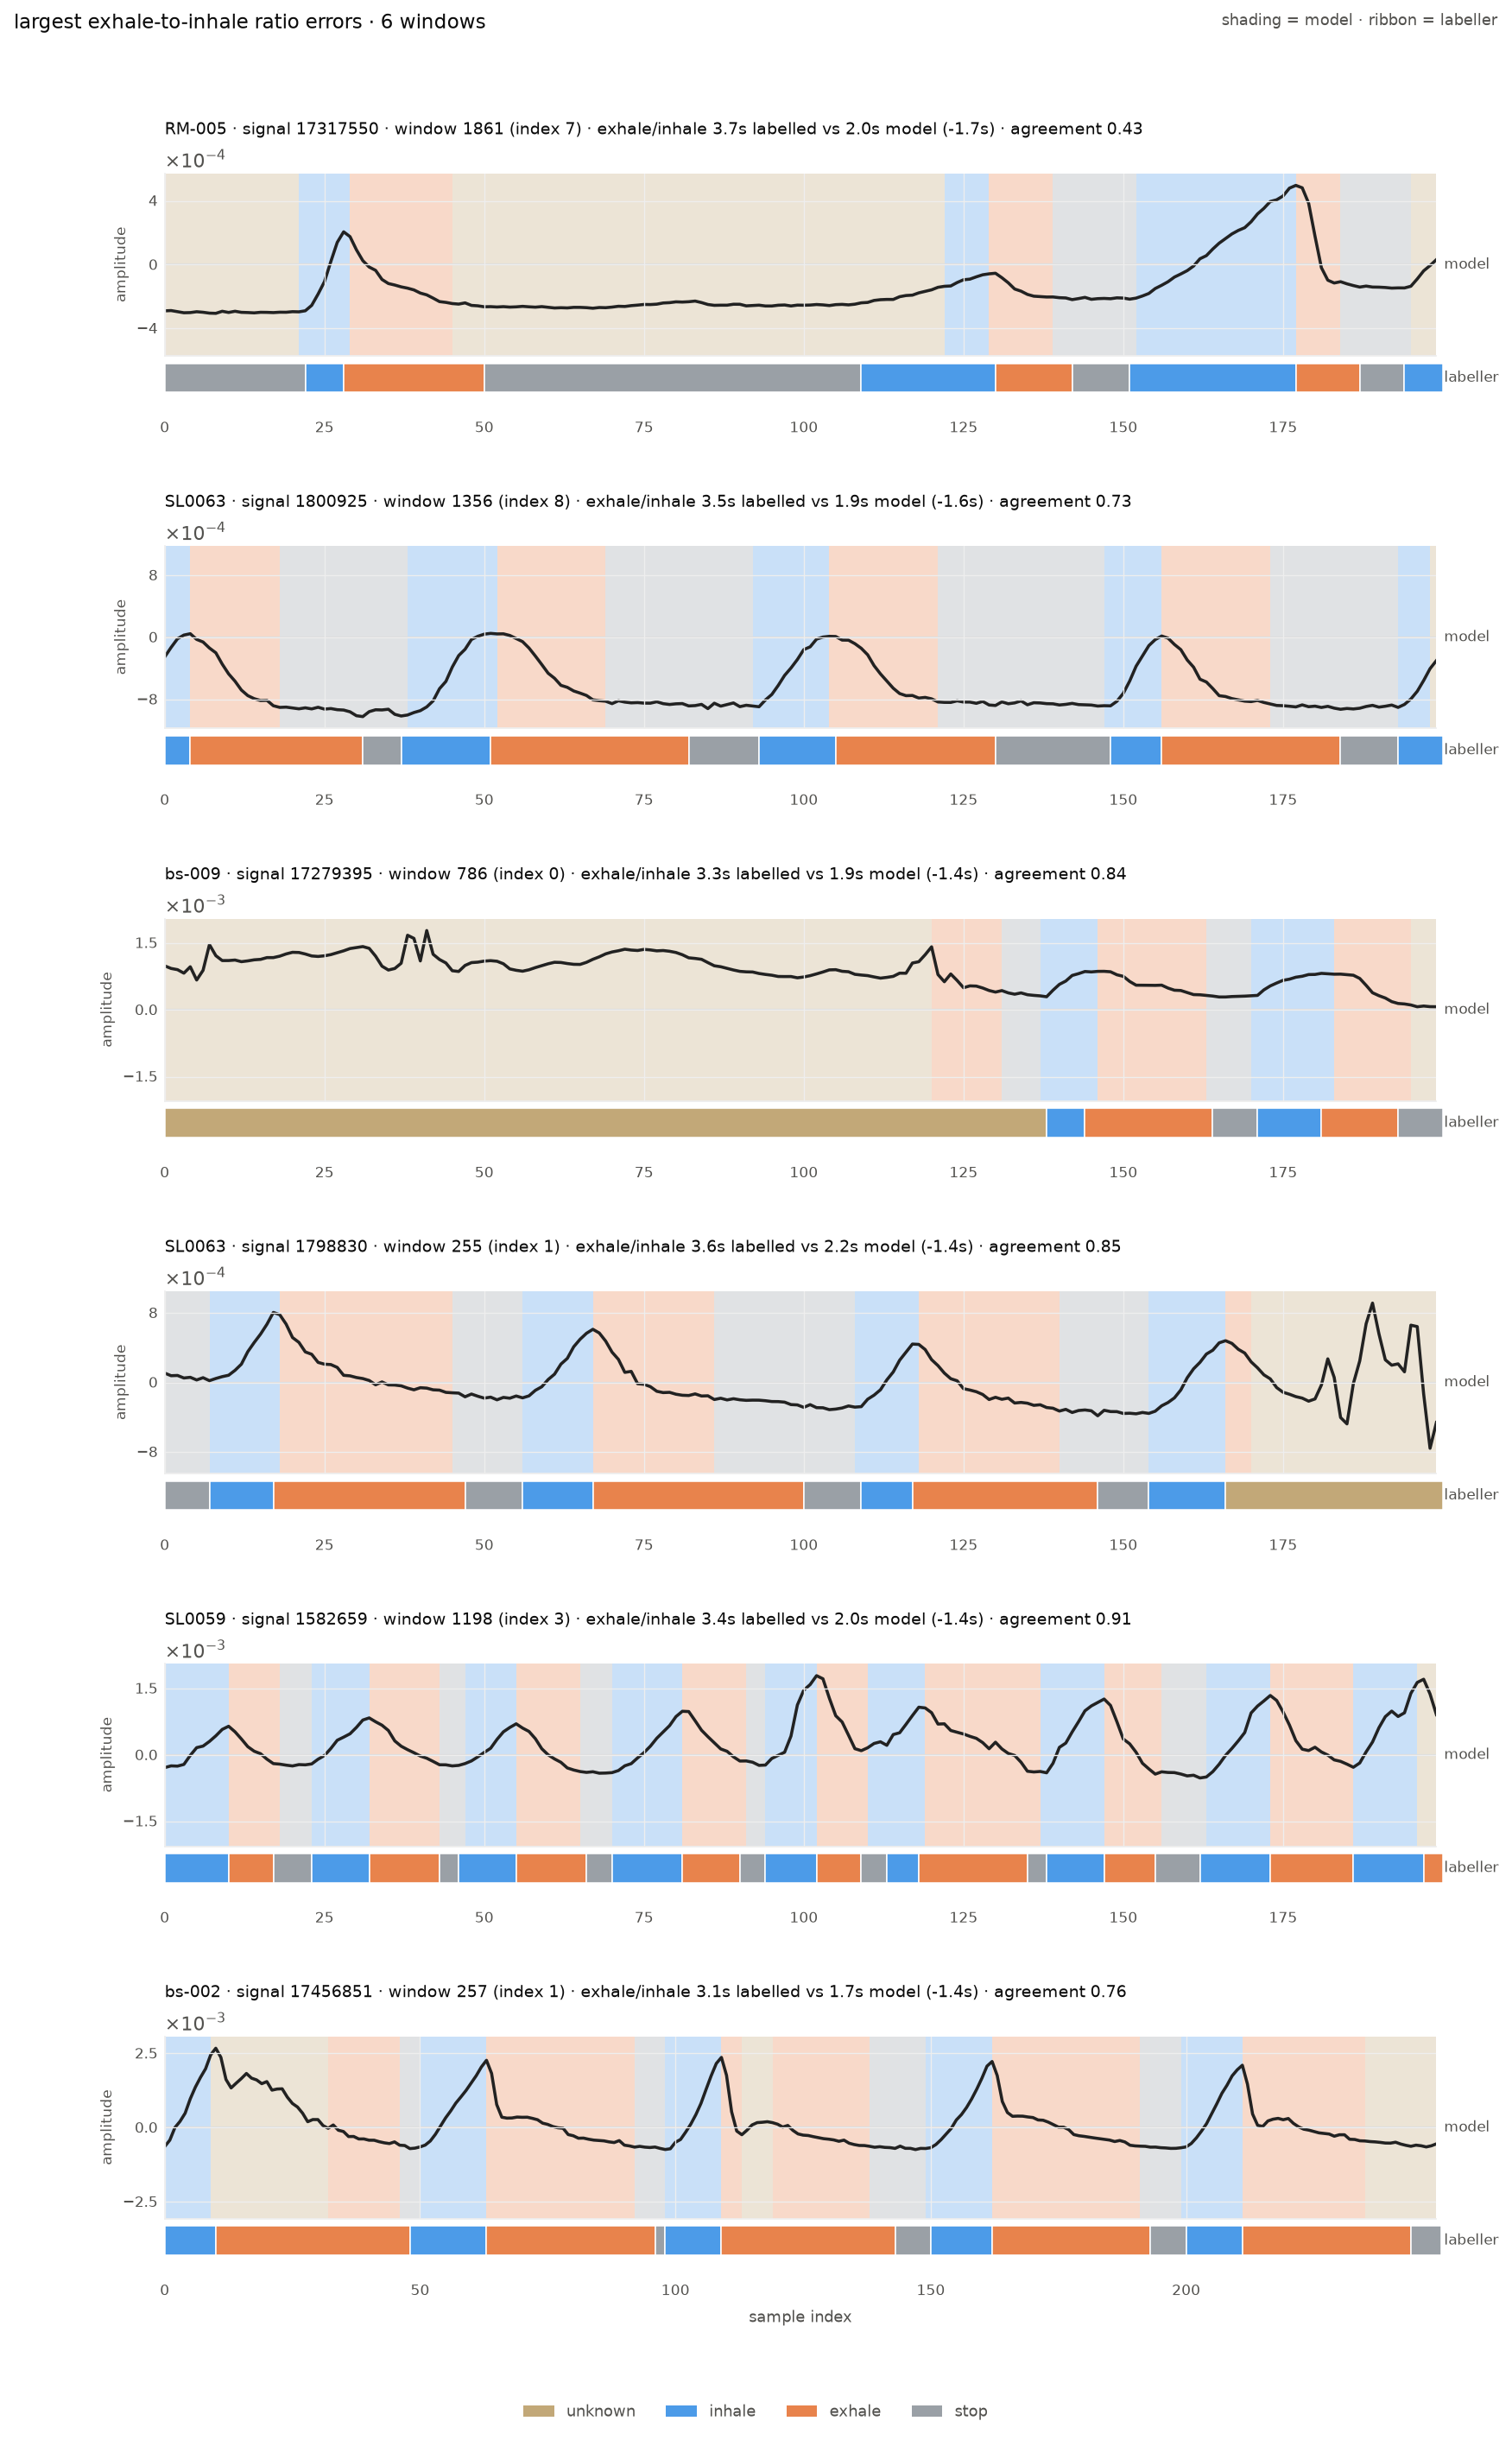

,env,signal,window_id,patient,labelled_sec,model_sec,error_sec
1045,ds_prod,17317550,1861,RM-005,3.67,2.00,-1.67
522,ds_algo,1800925,1356,SL0063,3.50,1.89,-1.61
969,ds_prod,17279395,786,bs-009,3.33,1.89,-1.44
482,ds_algo,1798830,255,SL0063,3.62,2.20,-1.42
231,ds_algo,1582659,1198,SL0059,3.40,2.00,-1.40
1240,ds_prod,17456851,257,bs-002,3.09,1.73,-1.36


In [9]:
ratio = pairs[pairs.phase == durations.RATIO].copy()
by_breath = pairs[pairs.phase.isin(['inhale', 'exhale'])]

worst_ratio = ratio.sort_values('abs_error', ascending=False).head(6)
chosen = worst_ratio.merge(per_window.drop(
    columns=['worst_phase', 'worst_signed', 'worst_labelled', 'worst_model']), on=KEYS)
chosen = chosen.assign(worst_phase='exhale/inhale',
                       worst_signed=chosen[durations.ERROR],
                       worst_labelled=chosen[f'{durations.LABEL}_sec'],
                       worst_model=chosen[f'{durations.MODEL}_sec'])
path = draw(chosen, 'worst_ratio.png', 'largest exhale-to-inhale ratio errors · 6 windows')
display(Image(filename=str(path)))
worst_ratio[KEYS + [f'{durations.LABEL}_sec', f'{durations.MODEL}_sec',
                    durations.ERROR]].round(2)

## What to take from it

Read the panels, not this list - but the questions worth asking of each one:

- Does the trace itself support the labeller's boundary, or is the model defensible?
- Is the error at the **start** or the **end** of the phase? A late onset and an early offset are
  different bugs, and the decoder's transition cost touches one of them.
- Does the window contain a genuine irregularity - a sigh, a movement artefact, an apnoea - that
  neither side should be scored on?

Everything drawn here is written to `out/duration_outliers/` alongside the two csvs, so a panel can
be pulled into a page or a ticket without re-running the notebook.